In [3]:
import copy
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from pymatgen.core import Element
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, GINEConv, global_mean_pool

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


### 1. Carga y revisión del dataset

In [4]:
gnn_df = pd.read_pickle("datos_baterias_mp/gnn_dataset.pkl")

print("Número de estructuras:", len(gnn_df))
print("Columnas:")
print(gnn_df.columns.tolist())

gnn_df.head()

Número de estructuras: 3476
Columnas:
['battery_formula', 'working_ion_dataset', 'average_voltage_dataset', 'capacity_grav_dataset', 'capacity_vol_dataset', 'energy_grav', 'energy_vol', 'max_delta_volume', 'max_voltage_step', 'stability_charge_dataset', 'stability_discharge_dataset', 'framework_formula', 'num_steps', 'last_updated', 'energy_estimada', 'index', 'working_ion_mp', 'average_voltage_mp', 'capacity_grav_mp', 'capacity_vol_mp', 'stability_charge_mp', 'stability_discharge_mp', 'n_atoms', 'volume', 'structure']


,battery_formula,working_ion_dataset,average_voltage_dataset,capacity_grav_dataset,capacity_vol_dataset,energy_grav,energy_vol,max_delta_volume,max_voltage_step,stability_charge_dataset,...,index,working_ion_mp,average_voltage_mp,capacity_grav_mp,capacity_vol_mp,stability_charge_mp,stability_discharge_mp,n_atoms,volume,structure
0,Cs0-3Ac,Cs,-0.707763,128.499827,404.648831,-90.947418,-286.395455,6.270133,0.0,0.020409,...,0.0,Cs,-0.707763,128.499827,404.648831,0.020409,0.535925,1.0,45.384600,[[0. 0. 0.] Ac]
1,Ca0-3Ac,Ca,-0.034773,463.113885,1586.172049,-16.103762,-55.155628,2.709372,0.0,0.020409,...,1.0,Ca,-0.034773,463.113885,1586.172049,0.020409,0.057262,1.0,45.384600,[[0. 0. 0.] Ac]
3,Na0-3Ag,Na,-0.008959,454.679804,1215.877630,-4.073349,-10.892707,5.098846,0.0,0.003609,...,3.0,Na,-0.008959,454.679804,1215.877630,0.003609,0.045182,1.0,18.004938,[[0. 0. 0.] Ag]
4,Li0-3Ag,Li,0.210565,624.785871,1984.816229,131.558310,417.933696,2.736089,0.0,0.003609,...,4.0,Li,0.210565,624.785871,1984.816229,0.003609,0.000000,1.0,18.004938,[[0. 0. 0.] Ag]
5,Mg5-149Ag,Mg,0.013563,2069.771606,3758.929988,28.072799,50.983251,26.114803,0.0,0.028915,...,5.0,Mg,0.013563,2069.771606,3758.929988,0.028915,0.000000,1.0,125.756281,[[0. 0. 0.] Ag]


In [5]:
required_columns = {
    "structure",
    "max_delta_volume",
    "framework_formula",
}

missing_columns = required_columns - set(gnn_df.columns)

if missing_columns:
    raise ValueError(
        f"Faltan columnas necesarias en el dataset: {sorted(missing_columns)}"
    )

print("Frameworks únicos:", gnn_df["framework_formula"].nunique())
print()
print("Frameworks más frecuentes:")
display(gnn_df["framework_formula"].value_counts().head(20))

Frameworks únicos: 1985

Frameworks más frecuentes:


framework_formula
MnO2      36
TiO2      29
CoO2      29
FeO2      28
CrO2      27
VO2       25
NiO2      22
Sb        21
MnBO3     17
FeP2O7    16
Sn        16
MnPO4     16
Ca        15
VF5       15
FePO4     14
CrO3      13
WO3       13
CrPO4     13
V2O5      13
MnP2O7    12
Name: count, dtype: int64

In [6]:
structure = gnn_df.iloc[0]["structure"]

print("Ejemplo de estructura:", structure.formula)
print("Número de átomos:", len(structure))
print("Target max_delta_volume:", gnn_df.iloc[0]["max_delta_volume"])

Ejemplo de estructura: Ac1
Número de átomos: 1
Target max_delta_volume: 6.27013285594635


### 2. Split train / validation / test

No se realiza un split aleatorio por filas. Varias estructuras pueden compartir el mismo `framework_formula`, por lo que un split convencional podría colocar estructuras del mismo framework tanto en entrenamiento como en validación/test.

- 70 % aproximadamente para entrenamiento.
- 15 % aproximadamente para validación.
- 15 % aproximadamente para test.

In [7]:
indices = np.arange(len(gnn_df))
groups = gnn_df["framework_formula"]

splitter_train = GroupShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=SEED,
)

train_idx, temp_idx = next(
    splitter_train.split(indices, groups=groups)
)

temp_groups = gnn_df.iloc[temp_idx]["framework_formula"]

splitter_val_test = GroupShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=SEED,
)

val_relative, test_relative = next(
    splitter_val_test.split(
        temp_idx,
        groups=temp_groups,
    )
)

val_idx = temp_idx[val_relative]
test_idx = temp_idx[test_relative]

print(f"Train:      {len(train_idx):5d} ({100 * len(train_idx) / len(gnn_df):6.2f} %)")
print(f"Validation: {len(val_idx):5d} ({100 * len(val_idx) / len(gnn_df):6.2f} %)")
print(f"Test:       {len(test_idx):5d} ({100 * len(test_idx) / len(gnn_df):6.2f} %)")

Train:       2428 ( 69.85 %)
Validation:   515 ( 14.82 %)
Test:         533 ( 15.33 %)


In [8]:
train_frameworks = set(gnn_df.iloc[train_idx]["framework_formula"])
val_frameworks = set(gnn_df.iloc[val_idx]["framework_formula"])
test_frameworks = set(gnn_df.iloc[test_idx]["framework_formula"])

print("Train ∩ Validation:", len(train_frameworks & val_frameworks))
print("Train ∩ Test:", len(train_frameworks & test_frameworks))
print("Validation ∩ Test:", len(val_frameworks & test_frameworks))

assert train_frameworks.isdisjoint(val_frameworks)
assert train_frameworks.isdisjoint(test_frameworks)
assert val_frameworks.isdisjoint(test_frameworks)

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


## 3. Construcción de los grafos

Cada estructura cristalina se representa como un grafo:

- **Nodos:** átomos.
- **Aristas:** vecinos periódicos dentro de un radio de corte (`cutoff`).
- **Características de nodo:**
  - configuración `"z"`: únicamente número atómico;
  - configuración `"atomic"`: número atómico, masa atómica, electronegatividad y radio atómico.
- **Característica de arista:** distancia interatómica en Å.
- **Target:** `max_delta_volume`.

La distancia se almacena siempre en `edge_attr`.

In [9]:
def get_atom_features(structure, feature_set="atomic"):
    features = []

    for site in structure:
        element = Element(site.specie.symbol)

        if feature_set == "z":
            atom_features = [
                float(element.Z),
            ]

        elif feature_set == "atomic":
            atom_features = [
                float(element.Z),
                float(element.atomic_mass),
                float(element.X) if element.X is not None else 0.0,
                float(element.atomic_radius) if element.atomic_radius is not None else 0.0,
            ]

        else:
            raise ValueError(
                "feature_set debe ser 'z' o 'atomic'."
            )

        features.append(atom_features)

    return torch.tensor(features, dtype=torch.float)

In [10]:
def structure_to_graph(
    structure,
    target,
    cutoff=5.0,
    feature_set="atomic",
):
    x = get_atom_features(
        structure,
        feature_set=feature_set,
    )

    edges = []
    edge_distances = []

    for i in range(len(structure)):
        neighbors = structure.get_neighbors(
            structure[i],
            cutoff,
        )

        for neighbor in neighbors:
            j = neighbor.index

            # Se omiten auto-conexiones.
            if i == j:
                continue

            edges.append([i, j])
            edge_distances.append([float(neighbor.nn_distance)])

    if edges:
        edge_index = torch.tensor(
            edges,
            dtype=torch.long,
        ).t().contiguous()

        edge_attr = torch.tensor(
            edge_distances,
            dtype=torch.float,
        )

    else:
        edge_index = torch.empty(
            (2, 0),
            dtype=torch.long,
        )

        edge_attr = torch.empty(
            (0, 1),
            dtype=torch.float,
        )

    y = torch.tensor(
        [float(target)],
        dtype=torch.float,
    )

    return Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=y,
    )

In [11]:
example_graph = structure_to_graph(
    structure=gnn_df.iloc[0]["structure"],
    target=gnn_df.iloc[0]["max_delta_volume"],
    cutoff=5.0,
    feature_set="atomic",
)

print(example_graph)
print("Nodos:", example_graph.num_nodes)
print("Aristas:", example_graph.num_edges)
print("Node features:", example_graph.x.shape)
print("Edge features:", example_graph.edge_attr.shape)
print("Target:", example_graph.y.item())

Data(x=[1, 4], edge_index=[2, 0], edge_attr=[0, 1], y=[1])
Nodos: 1
Aristas: 0
Node features: torch.Size([1, 4])
Edge features: torch.Size([0, 1])
Target: 6.270133018493652


### 4. Funciones auxiliares para datasets y DataLoaders

In [12]:
def build_graph_dataset(
    dataframe,
    cutoff,
    feature_set,
    target_transform=None,
):
    graphs = []

    for _, row in dataframe.iterrows():
        target = float(row["max_delta_volume"])

        if target_transform is not None:
            target = float(target_transform(target))

        graph = structure_to_graph(
            structure=row["structure"],
            target=target,
            cutoff=cutoff,
            feature_set=feature_set,
        )

        graphs.append(graph)

    return graphs


def create_loaders(
    graphs,
    train_idx,
    val_idx,
    test_idx,
    batch_size=32,
):
    train_graphs = [graphs[i] for i in train_idx]
    val_graphs = [graphs[i] for i in val_idx]
    test_graphs = [graphs[i] for i in test_idx]

    train_loader = DataLoader(
        train_graphs,
        batch_size=batch_size,
        shuffle=True,
    )

    val_loader = DataLoader(
        val_graphs,
        batch_size=batch_size,
        shuffle=False,
    )

    test_loader = DataLoader(
        test_graphs,
        batch_size=batch_size,
        shuffle=False,
    )

    return train_loader, val_loader, test_loader

### 5. Arquitecturas

In [13]:
class GCNRegressor(nn.Module):
    def __init__(
        self,
        in_channels,
        hidden_channels=64,
    ):
        super().__init__()

        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)

        self.fc1 = nn.Linear(hidden_channels, 32)
        self.fc2 = nn.Linear(32, 1)

    def forward(self, batch):
        x = batch.x
        edge_index = batch.edge_index

        x = torch.relu(self.conv1(x, edge_index))
        x = torch.relu(self.conv2(x, edge_index))
        x = torch.relu(self.conv3(x, edge_index))

        x = global_mean_pool(x, batch.batch)

        x = torch.relu(self.fc1(x))
        x = self.fc2(x)

        return x.squeeze(-1)


class GINERegressor(nn.Module):
    def __init__(
        self,
        in_channels=4,
        hidden_channels=64,
        edge_dim=1,
    ):
        super().__init__()

        mlp1 = nn.Sequential(
            nn.Linear(in_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, hidden_channels),
        )

        mlp2 = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, hidden_channels),
        )

        mlp3 = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, hidden_channels),
        )

        self.conv1 = GINEConv(mlp1, edge_dim=edge_dim)
        self.conv2 = GINEConv(mlp2, edge_dim=edge_dim)
        self.conv3 = GINEConv(mlp3, edge_dim=edge_dim)

        self.fc1 = nn.Linear(hidden_channels, 32)
        self.fc2 = nn.Linear(32, 1)

    def forward(self, batch):
        x = batch.x
        edge_index = batch.edge_index
        edge_attr = batch.edge_attr

        x = torch.relu(self.conv1(x, edge_index, edge_attr))
        x = torch.relu(self.conv2(x, edge_index, edge_attr))
        x = torch.relu(self.conv3(x, edge_index, edge_attr))

        x = global_mean_pool(x, batch.batch)

        x = torch.relu(self.fc1(x))
        x = self.fc2(x)

        return x.squeeze(-1)

### 6. Entrenamiento y evaluación comunes

In [14]:
def run_epoch(
    model,
    loader,
    criterion,
    device,
    optimizer=None,
):
    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_samples = 0

    context = torch.enable_grad() if is_training else torch.no_grad()

    with context:
        for batch in loader:
            batch = batch.to(device)

            if is_training:
                optimizer.zero_grad()

            prediction = model(batch)
            target = batch.y.view(-1)

            loss = criterion(
                prediction,
                target,
            )

            if is_training:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * batch.num_graphs
            total_samples += batch.num_graphs

    return total_loss / total_samples


def train_model(
    model,
    train_loader,
    val_loader,
    device,
    num_epochs=100,
    lr=1e-3,
    weight_decay=1e-5,
    criterion=None,
):
    if criterion is None:
        criterion = nn.HuberLoss(delta=1.0)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    train_losses = []
    val_losses = []

    best_val_loss = float("inf")
    best_state = None

    for epoch in range(1, num_epochs + 1):
        train_loss = run_epoch(
            model=model,
            loader=train_loader,
            criterion=criterion,
            device=device,
            optimizer=optimizer,
        )

        val_loss = run_epoch(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=device,
        )

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

        if epoch == 1 or epoch % 10 == 0:
            print(
                f"Epoch {epoch:03d} | "
                f"Train: {train_loss:.6f} | "
                f"Val: {val_loss:.6f}"
            )

    model.load_state_dict(best_state)
    model.to(device)

    history = {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "best_val_loss": best_val_loss,
    }

    return model, history

In [15]:
def predict(
    model,
    loader,
    device,
    inverse_transform=None,
):
    model.eval()

    predictions = []
    targets = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            prediction = model(batch)
            target = batch.y.view(-1)

            prediction = prediction.cpu().numpy()
            target = target.cpu().numpy()

            if inverse_transform is not None:
                prediction = inverse_transform(prediction)
                target = inverse_transform(target)

            predictions.extend(prediction)
            targets.extend(target)

    return np.asarray(targets), np.asarray(predictions)


def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }


def evaluate_model(
    model,
    loader,
    device,
    inverse_transform=None,
):
    y_true, y_pred = predict(
        model=model,
        loader=loader,
        device=device,
        inverse_transform=inverse_transform,
    )

    metrics = regression_metrics(
        y_true,
        y_pred,
    )

    return metrics, y_true, y_pred


def plot_history(history, title):
    plt.figure(figsize=(8, 5))
    plt.plot(history["train_loss"], label="Train")
    plt.plot(history["val_loss"], label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.show()


def plot_predictions(y_true, y_pred, title):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.5)

    minimum = min(y_true.min(), y_pred.min())
    maximum = max(y_true.max(), y_pred.max())

    plt.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--",
    )

    plt.xlabel("Valor real")
    plt.ylabel("Predicción")
    plt.title(title)
    plt.show()

### 7. Experimentos

| Modelo | Tipo | Features de nodo | Distancia en aristas | Cutoff | Target |
|---|---|---|---|---:|---|
| 1 | GCN | Número atómico (Z) | No utilizada | 5 Å | Original |
| 2 | GCN | Z + masa + electronegatividad + radio | No utilizada | 4 Å | Original |
| 3 | GINE | Z + masa + electronegatividad + radio | Sí | 4 Å | Original |
| 4 | GINE | Z + masa + electronegatividad + radio | Sí | 4 Å | `log1p(target)` |

### 7.1 Modelo 1 — GCN con número atómico

In [16]:
graphs_b1 = build_graph_dataset(
    dataframe=gnn_df,
    cutoff=5.0,
    feature_set="z",
)

train_loader_b1, val_loader_b1, test_loader_b1 = create_loaders(
    graphs=graphs_b1,
    train_idx=train_idx,
    val_idx=val_idx,
    test_idx=test_idx,
)

model_b1 = GCNRegressor(
    in_channels=1,
    hidden_channels=64,
).to(device)

model_b1, history_b1 = train_model(
    model=model_b1,
    train_loader=train_loader_b1,
    val_loader=val_loader_b1,
    device=device,
)

metrics_b1, y_true_b1, y_pred_b1 = evaluate_model(
    model=model_b1,
    loader=test_loader_b1,
    device=device,
)

print(metrics_b1)

Epoch 001 | Train: 0.679736 | Val: 0.134970
Epoch 010 | Train: 0.667250 | Val: 0.121573
Epoch 020 | Train: 0.663487 | Val: 0.120657
Epoch 030 | Train: 0.662957 | Val: 0.119896
Epoch 040 | Train: 0.661037 | Val: 0.113019
Epoch 050 | Train: 0.660373 | Val: 0.106808
Epoch 060 | Train: 0.660902 | Val: 0.112103
Epoch 070 | Train: 0.658371 | Val: 0.104398
Epoch 080 | Train: 0.660025 | Val: 0.106915
Epoch 090 | Train: 0.657252 | Val: 0.103853
Epoch 100 | Train: 0.659174 | Val: 0.105089
{'MAE': 0.44675523042678833, 'RMSE': np.float64(2.863758833166825), 'R2': 0.09517991542816162}


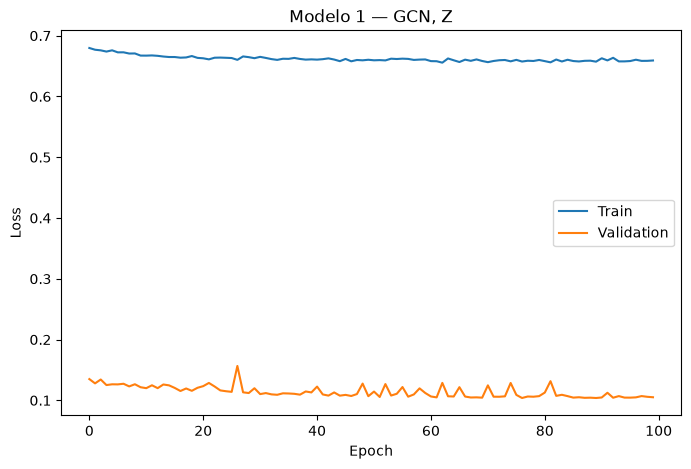

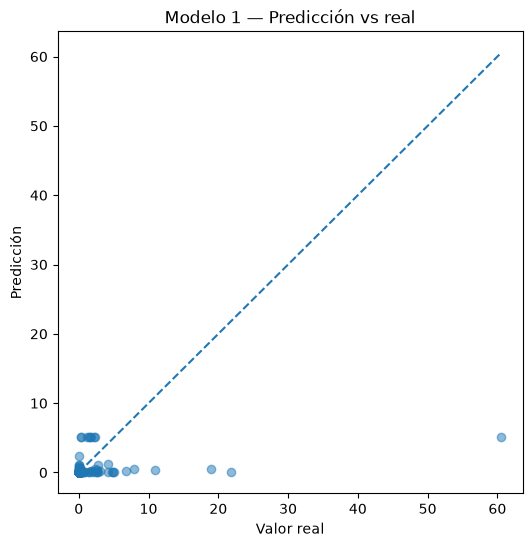

In [17]:
plot_history(history_b1, "Modelo 1 — GCN, Z")
plot_predictions(y_true_b1, y_pred_b1, "Modelo 1 — Predicción vs real")

### 7.2 Modelo 2 — GCN con características atómicas

In [18]:
graphs_b2 = build_graph_dataset(
    dataframe=gnn_df,
    cutoff=4.0,
    feature_set="atomic",
)

train_loader_b2, val_loader_b2, test_loader_b2 = create_loaders(
    graphs=graphs_b2,
    train_idx=train_idx,
    val_idx=val_idx,
    test_idx=test_idx,
)

model_b2 = GCNRegressor(
    in_channels=4,
    hidden_channels=64,
).to(device)

model_b2, history_b2 = train_model(
    model=model_b2,
    train_loader=train_loader_b2,
    val_loader=val_loader_b2,
    device=device,
)

metrics_b2, y_true_b2, y_pred_b2 = evaluate_model(
    model=model_b2,
    loader=test_loader_b2,
    device=device,
)

print(metrics_b2)

Epoch 001 | Train: 0.687667 | Val: 0.125905
Epoch 010 | Train: 0.670788 | Val: 0.128306
Epoch 020 | Train: 0.658804 | Val: 0.113978
Epoch 030 | Train: 0.659892 | Val: 0.133973
Epoch 040 | Train: 0.660163 | Val: 0.113446
Epoch 050 | Train: 0.651639 | Val: 0.128595
Epoch 060 | Train: 0.651140 | Val: 0.116591
Epoch 070 | Train: 0.647297 | Val: 0.112199
Epoch 080 | Train: 0.643422 | Val: 0.114480
Epoch 090 | Train: 0.640831 | Val: 0.105614
Epoch 100 | Train: 0.643374 | Val: 0.108672
{'MAE': 0.3994675576686859, 'RMSE': np.float64(2.797113845259482), 'R2': 0.13680356740951538}


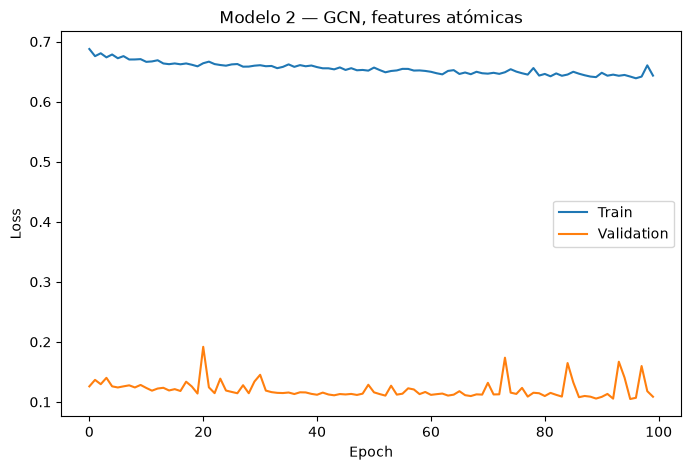

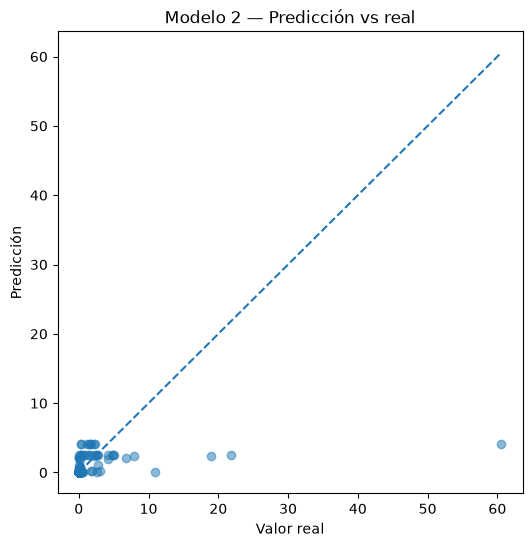

In [19]:
plot_history(history_b2, "Modelo 2 — GCN, features atómicas")
plot_predictions(y_true_b2, y_pred_b2, "Modelo 2 — Predicción vs real")

### 7.3 Modelo 3 — GINE con distancia interatómica

In [20]:
train_loader_b3, val_loader_b3, test_loader_b3 = create_loaders(
    graphs=graphs_b2,
    train_idx=train_idx,
    val_idx=val_idx,
    test_idx=test_idx,
)

model_b3 = GINERegressor(
    in_channels=4,
    hidden_channels=64,
    edge_dim=1,
).to(device)

model_b3, history_b3 = train_model(
    model=model_b3,
    train_loader=train_loader_b3,
    val_loader=val_loader_b3,
    device=device,
)

metrics_b3, y_true_b3, y_pred_b3 = evaluate_model(
    model=model_b3,
    loader=test_loader_b3,
    device=device,
)

print(metrics_b3)

Epoch 001 | Train: 10.644355 | Val: 3.170069
Epoch 010 | Train: 0.630757 | Val: 0.105318
Epoch 020 | Train: 0.634008 | Val: 0.139727
Epoch 030 | Train: 0.612770 | Val: 0.100195
Epoch 040 | Train: 0.611512 | Val: 0.101682
Epoch 050 | Train: 0.611995 | Val: 0.112304
Epoch 060 | Train: 0.609197 | Val: 0.101645
Epoch 070 | Train: 0.608760 | Val: 0.101662
Epoch 080 | Train: 0.609509 | Val: 0.100765
Epoch 090 | Train: 0.607971 | Val: 0.099985
Epoch 100 | Train: 0.614711 | Val: 0.103679
{'MAE': 0.36961236596107483, 'RMSE': np.float64(2.7204189220560706), 'R2': 0.18349111080169678}


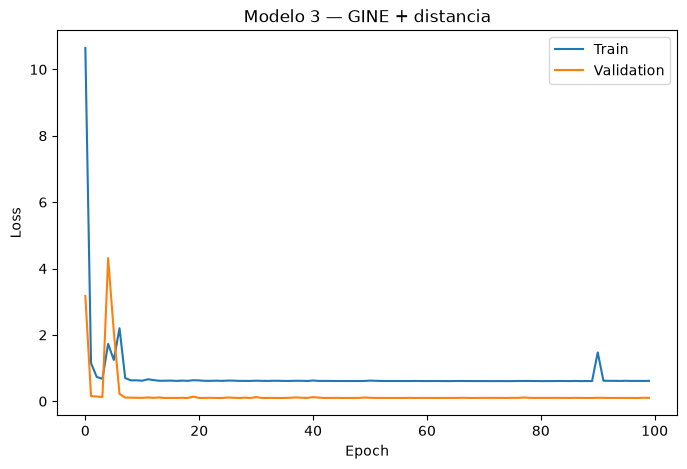

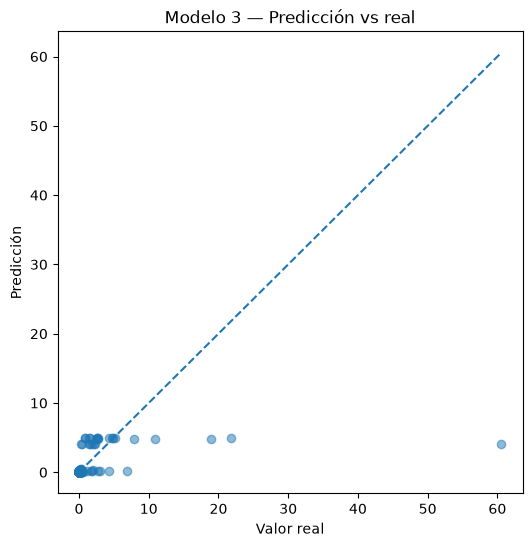

In [21]:
plot_history(history_b3, "Modelo 3 — GINE + distancia")
plot_predictions(y_true_b3, y_pred_b3, "Modelo 3 — Predicción vs real")

### 7.4 Modelo 4 — GINE con transformación logarítmica del target

In [22]:
if (gnn_df["max_delta_volume"] <= -1).any():
    raise ValueError(
        "log1p no es válido para targets <= -1."
    )

graphs_b4 = build_graph_dataset(
    dataframe=gnn_df,
    cutoff=4.0,
    feature_set="atomic",
    target_transform=np.log1p,
)

train_loader_b4, val_loader_b4, test_loader_b4 = create_loaders(
    graphs=graphs_b4,
    train_idx=train_idx,
    val_idx=val_idx,
    test_idx=test_idx,
)

model_b4 = GINERegressor(
    in_channels=4,
    hidden_channels=64,
    edge_dim=1,
).to(device)

model_b4, history_b4 = train_model(
    model=model_b4,
    train_loader=train_loader_b4,
    val_loader=val_loader_b4,
    device=device,
)

metrics_b4, y_true_b4, y_pred_b4 = evaluate_model(
    model=model_b4,
    loader=test_loader_b4,
    device=device,
    inverse_transform=np.expm1,
)

print(metrics_b4)

Epoch 001 | Train: 12.134813 | Val: 0.081281
Epoch 010 | Train: 0.056377 | Val: 0.020158
Epoch 020 | Train: 0.049103 | Val: 0.027201
Epoch 030 | Train: 0.055129 | Val: 0.030652
Epoch 040 | Train: 0.044161 | Val: 0.021775
Epoch 050 | Train: 0.044272 | Val: 0.018735
Epoch 060 | Train: 0.043087 | Val: 0.019556
Epoch 070 | Train: 0.041863 | Val: 0.017461
Epoch 080 | Train: 0.042634 | Val: 0.021122
Epoch 090 | Train: 0.041888 | Val: 0.019164
Epoch 100 | Train: 0.040117 | Val: 0.019726
{'MAE': 0.3691694438457489, 'RMSE': np.float64(2.7481403131602744), 'R2': 0.16676533222198486}


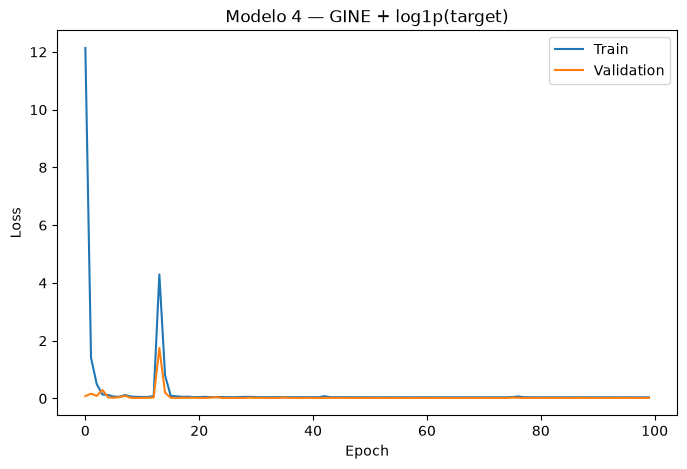

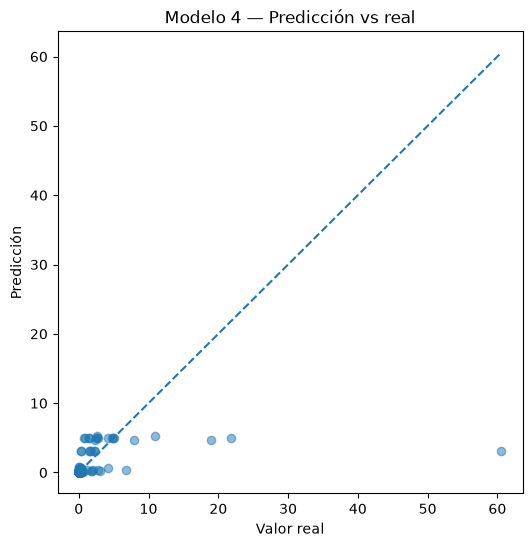

In [23]:
plot_history(history_b4, "Modelo 4 — GINE + log1p(target)")
plot_predictions(y_true_b4, y_pred_b4, "Modelo 4 — Predicción vs real")

### 8. Comparación de resultados

In [24]:
results = pd.DataFrame(
    [
        {
            "Modelo": "Modelo 1",
            "Arquitectura": "GCN",
            **metrics_b1,
        },
        {
            "Modelo": "Modelo 2",
            "Arquitectura": "GCN",
            **metrics_b2,
        },
        {
            "Modelo": "Modelo 3",
            "Arquitectura": "GINE",
            **metrics_b3,
        },
        {
            "Modelo": "Modelo 4",
            "Arquitectura": "GINE + log target",
            **metrics_b4,
        },
    ]
)

results.sort_values("MAE").reset_index(drop=True)

,Modelo,Arquitectura,MAE,RMSE,R2
0,Modelo 4,GINE + log target,0.369169,2.748140,0.166765
1,Modelo 3,GINE,0.369612,2.720419,0.183491
2,Modelo 2,GCN,0.399468,2.797114,0.136804
3,Modelo 1,GCN,0.446755,2.863759,0.095180


### 9. Análisis de los grafos

Se utiliza el conjunto de grafos con características atómicas y cutoff de 4 Å, que corresponde a los Modelos 2 y 3, para inspeccionar el tamaño de las estructuras.

In [25]:
num_nodes = np.asarray([
    graph.num_nodes
    for graph in graphs_b2
])

num_edges = np.asarray([
    graph.num_edges
    for graph in graphs_b2
])

print("Nodos por grafo")
print("  Media:  ", num_nodes.mean())
print("  Mediana:", np.median(num_nodes))
print("  Máximo: ", num_nodes.max())
print()

print("Aristas por grafo")
print("  Media:  ", num_edges.mean())
print("  Mediana:", np.median(num_edges))
print("  Máximo: ", num_edges.max())
print()

print("Grafos sin aristas:", np.sum(num_edges == 0))

Nodos por grafo
  Media:   24.026179516685847
  Mediana: 18.0
  Máximo:  144

Aristas por grafo
  Media:   437.367663981588
  Mediana: 352.0
  Máximo:  2584

Grafos sin aristas: 143


In [26]:
idx_max_edges = int(np.argmax(num_edges))
graph_max_edges = graphs_b2[idx_max_edges]

print("Grafo con más aristas")
print("Índice:", idx_max_edges)
print("Nodos:", graph_max_edges.num_nodes)
print("Aristas:", graph_max_edges.num_edges)
print("Target:", graph_max_edges.y.item())

if "battery_formula" in gnn_df.columns:
    print("Battery formula:", gnn_df.iloc[idx_max_edges]["battery_formula"])

print("Framework:", gnn_df.iloc[idx_max_edges]["framework_formula"])

Grafo con más aristas
Índice: 430
Nodos: 120
Aristas: 2584
Target: 0.032824672758579254
Battery formula: K0-0.02C
Framework: C


### 10. Inspección del target (max_delta_volume)



In [27]:
y_train = gnn_df.iloc[train_idx]["max_delta_volume"].to_numpy()
y_val = gnn_df.iloc[val_idx]["max_delta_volume"].to_numpy()
y_test = gnn_df.iloc[test_idx]["max_delta_volume"].to_numpy()

target_summary = pd.DataFrame(
    {
        "Train": pd.Series(y_train).describe(),
        "Validation": pd.Series(y_val).describe(),
        "Test": pd.Series(y_test).describe(),
    }
)

display(target_summary)

,Train,Validation,Test
count,2428.000000,515.000000,533.000000
mean,0.806998,0.215458,0.434734
std,9.333171,1.133263,3.013444
min,0.000016,0.000018,0.000080
25%,0.022731,0.022318,0.025998
50%,0.054800,0.055002,0.065928
75%,0.117280,0.105547,0.136707
max,293.193218,17.497218,60.585409


In [28]:
columns_to_show = [
    column
    for column in [
        "battery_formula",
        "framework_formula",
        "max_delta_volume",
        "n_atoms",
        "volume",
    ]
    if column in gnn_df.columns
]

gnn_df.nlargest(
    20,
    "max_delta_volume",
)[columns_to_show]

,battery_formula,framework_formula,max_delta_volume,n_atoms,volume
6250,Mg0-149Ni,Ni,293.193218,1.0,11.645268
5349,Mg0-149Fe,Fe,267.323478,1.0,12.852845
3030,Mg0-149Mo,Mo,199.434027,1.0,17.049839
3691,Mg1-149Sb,Sb,66.369015,1.0,51.330629
605,Mg1-149Bi,Bi,60.585409,1.0,56.243843
2314,Cs0-2HgSe,HgSe,28.239339,2.0,61.749310
5,Mg5-149Ag,Ag,26.114803,1.0,125.756281
3757,Mg5-149Ti,Ti,25.036005,1.0,131.119741
3733,Mg5-149Sn,Sn,23.304347,1.0,140.648100
3936,Cs0-2HCl,HCl,22.470407,2.0,53.069998
